# 🩺 Diabetes Prediction
## Diabetes Prediction using Machine Learning

This notebook follows the CardioSense workflow: data loading, quality checks, EDA, model training/comparison, evaluation, and saving the model for the Streamlit app.

**Dataset:** `../data/diabetes.csv` (768 rows; target column `Outcome`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


## ETL: Extract

In [4]:
df = pd.read_csv("../data/diabetes.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Understand the Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


## Data Quality Check

In [8]:
print("Missing values:\
", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)

Missing values: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicate rows: 0
Shape after removing duplicates: (768, 9)


In [9]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


## Target Distribution

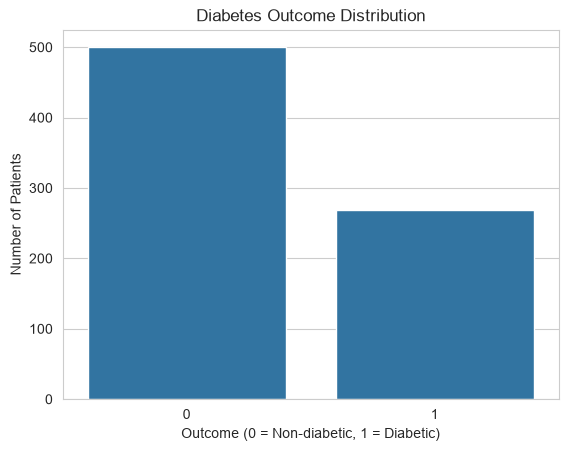

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


In [10]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.show()
print((df["Outcome"].value_counts(normalize=True) * 100).round(2))


## Exploratory Data Analysis

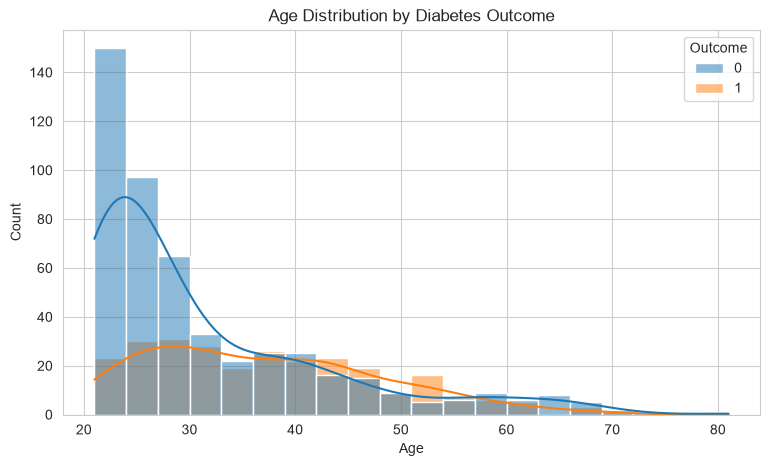

In [11]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="Age", hue="Outcome", kde=True, bins=20)
plt.title("Age Distribution by Diabetes Outcome")
plt.show()


## Glucose Analysis

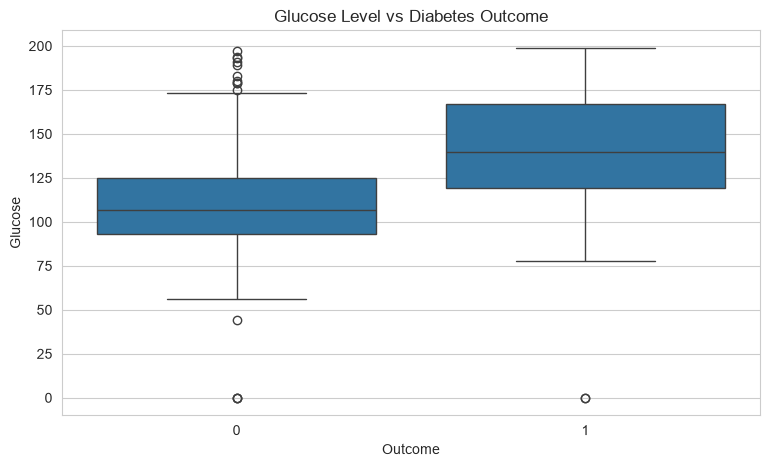

In [12]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Outcome", y="Glucose")
plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Outcome")
plt.show()


## BMI Analysis

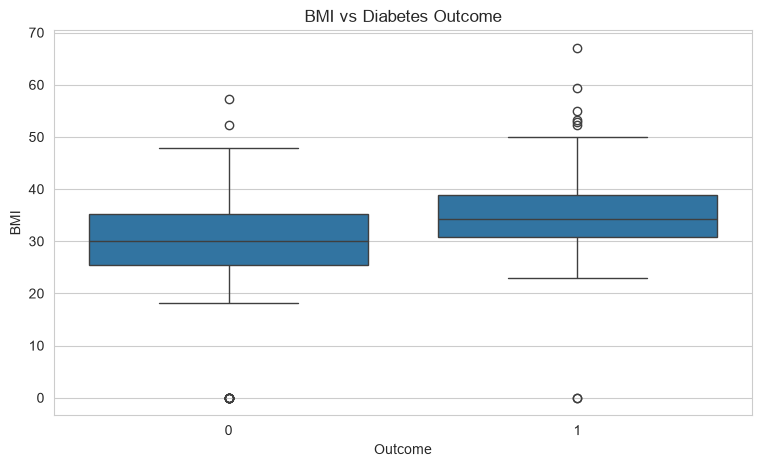

In [13]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Outcome", y="BMI")
plt.title("BMI vs Diabetes Outcome")
plt.show()


## Correlation Heatmap

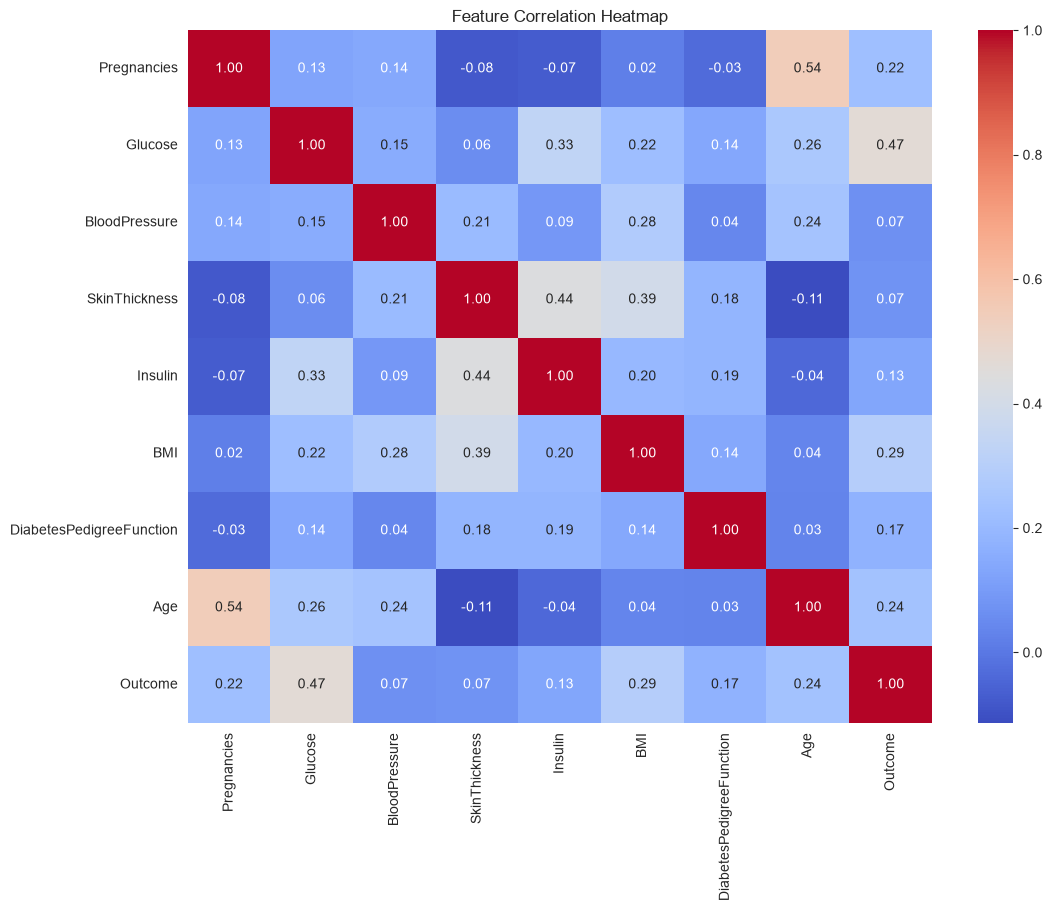

In [14]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


## Feature / Target Separation

In [15]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
features = list(X.columns)
print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (614, 8)
Testing data: (154, 8)


## Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train Multiple Models

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


## Train Models

In [19]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled if name in ["KNN", "Logistic Regression"] else X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")


Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
KNN trained successfully!


## Model Evaluation

In [20]:
results = []
for name, model in trained_models.items():
    data = X_test_scaled if name in ["KNN", "Logistic Regression"] else X_test
    pred = model.predict(data)
    prob = model.predict_proba(data)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, prob)
    })
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.746753,0.653061,0.592593,0.621359,0.813333
1,Decision Tree,0.727273,0.642857,0.500000,0.562500,0.675000
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
3,KNN,0.701299,0.583333,0.518519,0.549020,0.740463


## Model Comparison Visualization

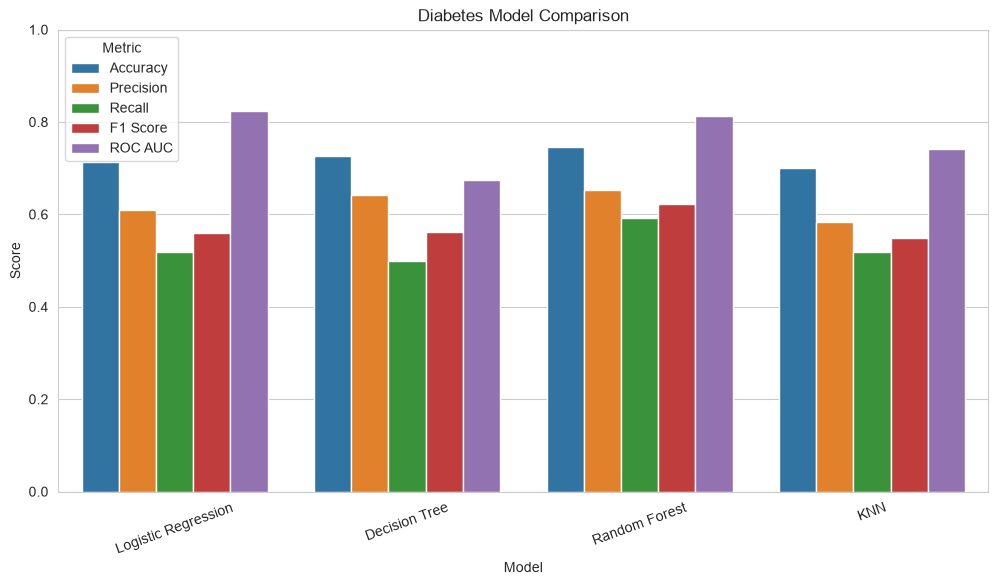

In [21]:
results_melted = results_df.melt(id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    var_name="Metric", value_name="Score")
plt.figure(figsize=(12,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0,1)
plt.title("Diabetes Model Comparison")
plt.xticks(rotation=20)
plt.show()


## Select Model

In [22]:
best_model_name = results_df.loc[results_df["F1 Score"].idxmax(), "Model"]
best_model = trained_models[best_model_name]
print("Selected model:", best_model_name)


Selected model: Random Forest


## Confusion Matrix & Classification Report

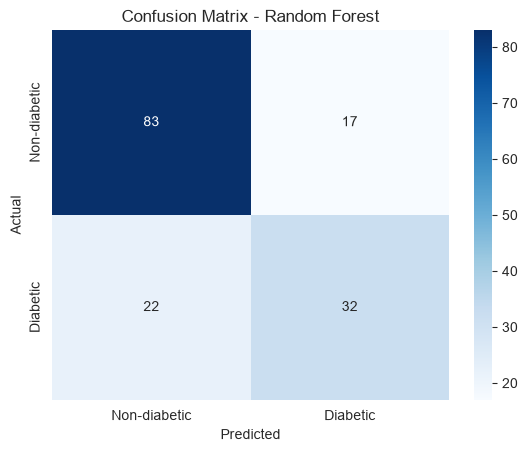

              precision    recall  f1-score   support

Non-diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



In [23]:
best_test_data = X_test_scaled if best_model_name in ["KNN", "Logistic Regression"] else X_test
y_pred = best_model.predict(best_test_data)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-diabetic", "Diabetic"],
    yticklabels=["Non-diabetic", "Diabetic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()
print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"], zero_division=0))


## ROC Curve

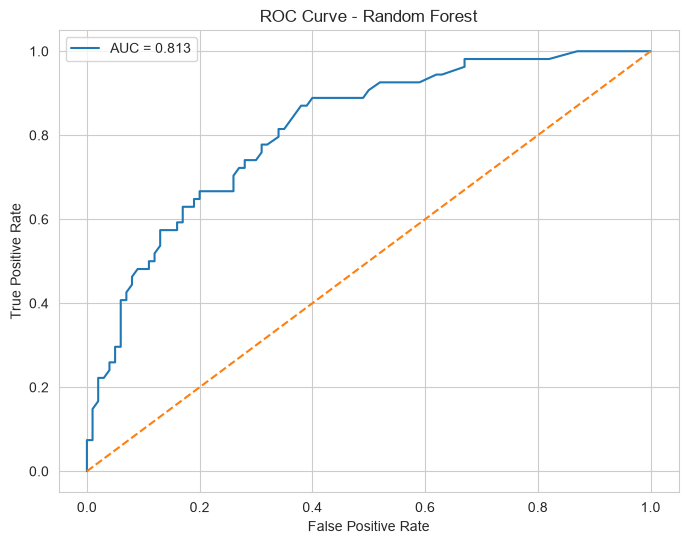

In [24]:
y_probability = best_model.predict_proba(best_test_data)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probability)
auc_score = roc_auc_score(y_test, y_probability)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()


## Save Model for Streamlit App
The app loads this package from `models/diabetes_model.pkl`. Run this notebook from its project notebook directory, with the project `models` folder available.

In [25]:
model_package = {
    "model": best_model,
    "scaler": scaler,
    "model_name": best_model_name,
    "features": features
}
joblib.dump(model_package, "../models/diabetes_model.pkl")
print("Model saved successfully to ../models/diabetes_model.pkl")


Model saved successfully to ../models/diabetes_model.pkl


## Test a Single Prediction

In [26]:
sample = X_test.iloc[[0]]
sample_data = scaler.transform(sample) if best_model_name in ["KNN", "Logistic Regression"] else sample
prediction = best_model.predict(sample_data)[0]
probability = best_model.predict_proba(sample_data)[0][1]
print("Predicted outcome:", prediction, "(1 = diabetic, 0 = non-diabetic)")
print(f"Estimated probability: {probability:.2%}")


Predicted outcome: 1 (1 = diabetic, 0 = non-diabetic)
Estimated probability: 69.00%


> **Note:** This is an educational machine-learning demonstration, not a medical diagnosis. Model probabilities are not a substitute for clinical assessment.